# BERT vs TF-IDF: Sentiment Analysis on SST-2 (GLUE Benchmark)
**Run on Colab with GPU runtime (Runtime → Change runtime type → T4 GPU)**

In [ ]:
!pip install transformers datasets scikit-learn torch seaborn -q

In [ ]:
import os, random, json
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback
)
from datasets import load_dataset
import transformers

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cpu':
    print('WARNING: No GPU — go to Runtime → Change runtime type → T4 GPU')

os.makedirs('outputs', exist_ok=True)
print(f'transformers version: {transformers.__version__}')

Device: cuda
transformers version: 5.0.0


## 1. Load SST-2 (GLUE Benchmark)

In [ ]:
# SST-2 is part of the GLUE benchmark — one line to load
dataset = load_dataset('glue', 'sst2')

# SST-2 test set labels are hidden (GLUE competition), so we use validation as test
train_ds = dataset['train']
test_ds  = dataset['validation']   # 872 samples, labels available

train_texts = train_ds['sentence']
train_labels = np.array(train_ds['label'])
test_texts  = test_ds['sentence']
test_labels = np.array(test_ds['label'])

label_names = ['negative', 'positive']
num_labels  = 2

print(f'Train: {len(train_texts)} | Test: {len(test_texts)}')
print(f'Label distribution — Train: {np.bincount(train_labels)} | Test: {np.bincount(test_labels)}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Train: 67349 | Test: 872
Label distribution — Train: [29780 37569] | Test: [428 444]


## 2. Baseline: TF-IDF + Logistic Regression

In [ ]:
print('Training TF-IDF + Logistic Regression baseline...')
tfidf = TfidfVectorizer(ngram_range=(1, 3), max_features=50_000, sublinear_tf=True)
X_train = tfidf.fit_transform(train_texts)
X_test  = tfidf.transform(test_texts)

lr = LogisticRegression(max_iter=1000, C=1, random_state=SEED)
lr.fit(X_train, train_labels)
baseline_preds = lr.predict(X_test)

bl_acc = accuracy_score(test_labels, baseline_preds)
bl_f1  = f1_score(test_labels, baseline_preds, average='macro')
print(f'Baseline  Accuracy: {bl_acc:.4f} | Macro F1: {bl_f1:.4f}')
print(classification_report(test_labels, baseline_preds, target_names=label_names))

Training TF-IDF + Logistic Regression baseline...
Baseline  Accuracy: 0.8108 | Macro F1: 0.8101
              precision    recall  f1-score   support

    negative       0.84      0.76      0.80       428
    positive       0.79      0.86      0.82       444

    accuracy                           0.81       872
   macro avg       0.81      0.81      0.81       872
weighted avg       0.81      0.81      0.81       872



## 3. BERT Fine-tuning

**Note on load warnings:** When loading `bert-base-uncased` for classification, you will see:
- `classifier.weight / classifier.bias → MISSING` — correct, new head randomly initialized, this is what gets trained
- `cls.predictions.* → UNEXPECTED` — old MLM head being dropped, safe to ignore

In [ ]:
MODEL_NAME = 'bert-base-uncased'
MAX_LEN    = 64    # SST-2 sentences are short (~20 tokens avg), 64 is plenty

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch['sentence'],
        truncation=True,
        padding='max_length',
        max_length=MAX_LEN
    )

# Tokenize — keep only needed columns
train_tok = train_ds.map(tokenize, batched=True, remove_columns=['sentence', 'idx'])
test_tok  = test_ds.map(tokenize,  batched=True, remove_columns=['sentence', 'idx'])

# Split train → 90% train / 10% val
split     = train_tok.train_test_split(test_size=0.1, seed=SEED)
train_tok = split['train']
val_tok   = split['test']

train_tok.set_format('torch')
val_tok.set_format('torch')
test_tok.set_format('torch')

print(f'Train: {len(train_tok)} | Val: {len(val_tok)} | Test: {len(test_tok)}')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Train: 60614 | Val: 6735 | Test: 872


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': float(accuracy_score(labels, preds)),
        'f1_macro': float(f1_score(labels, preds, average='macro'))
    }

model   = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)
use_gpu = torch.cuda.is_available()

# Version-safe TrainingArguments — works on any transformers version
tf_ver = tuple(int(x) for x in transformers.__version__.split('.')[:2])
eval_strat_key = 'eval_strategy' if tf_ver >= (4, 46) else 'evaluation_strategy'
warmup_kwargs  = {'warmup_ratio': 0.1} if tf_ver < (5, 0) else {'warmup_steps': 100}
print(f'Using: {eval_strat_key}, {list(warmup_kwargs.keys())[0]}')

args = TrainingArguments(
    output_dir='outputs/bert_model',
    num_train_epochs=4,
    per_device_train_batch_size=32,   # SST-2 is short texts, 32 fits fine
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    **warmup_kwargs,
    lr_scheduler_type='cosine',
    **{eval_strat_key: 'epoch'},
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    logging_steps=100,
    fp16=use_gpu,
    dataloader_pin_memory=use_gpu,
    seed=SEED,
    report_to='none',
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using: eval_strategy, warmup_steps


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.158950,0.147792,0.951745,0.951379
2,0.111072,0.162071,0.954863,0.954522
3,0.074313,0.179389,0.954863,0.954455
4,0.035392,0.202251,0.954714,0.954288


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=7580, training_loss=0.11350497476029207, metrics={'train_runtime': 1021.1017, 'train_samples_per_second': 237.446, 'train_steps_per_second': 7.423, 'total_flos': 7974106754795520.0, 'train_loss': 0.11350497476029207, 'epoch': 4.0})

## 4. Evaluate BERT

In [ ]:
preds_out  = trainer.predict(test_tok)
bert_preds = np.argmax(preds_out.predictions, axis=-1)
bert_true  = preds_out.label_ids

bert_acc = accuracy_score(bert_true, bert_preds)
bert_f1  = f1_score(bert_true, bert_preds, average='macro')

print(f'BERT Accuracy: {bert_acc:.4f} | Macro F1: {bert_f1:.4f}')
print(classification_report(bert_true, bert_preds, target_names=label_names))

BERT Accuracy: 0.9266 | Macro F1: 0.9265
              precision    recall  f1-score   support

    negative       0.94      0.91      0.92       428
    positive       0.92      0.94      0.93       444

    accuracy                           0.93       872
   macro avg       0.93      0.93      0.93       872
weighted avg       0.93      0.93      0.93       872



## 5. Visualisations

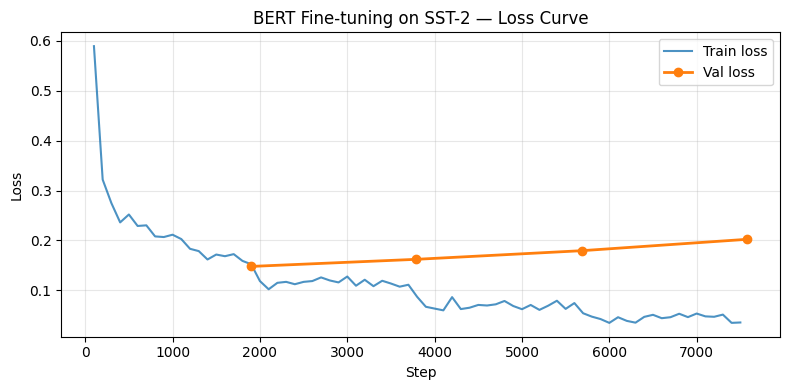

Saved outputs/loss_curve.png


In [ ]:
# --- Training loss curve ---
log_history = trainer.state.log_history
train_steps = [e['step'] for e in log_history if 'loss' in e and 'eval_loss' not in e]
train_loss  = [e['loss'] for e in log_history if 'loss' in e and 'eval_loss' not in e]
val_steps   = [e['step'] for e in log_history if 'eval_loss' in e]
val_loss    = [e['eval_loss'] for e in log_history if 'eval_loss' in e]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_steps, train_loss, label='Train loss', alpha=0.8)
ax.plot(val_steps,   val_loss,   label='Val loss', marker='o', linewidth=2)
ax.set_xlabel('Step'); ax.set_ylabel('Loss')
ax.set_title('BERT Fine-tuning on SST-2 — Loss Curve')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/loss_curve.png', dpi=150)
plt.show()
print('Saved outputs/loss_curve.png')

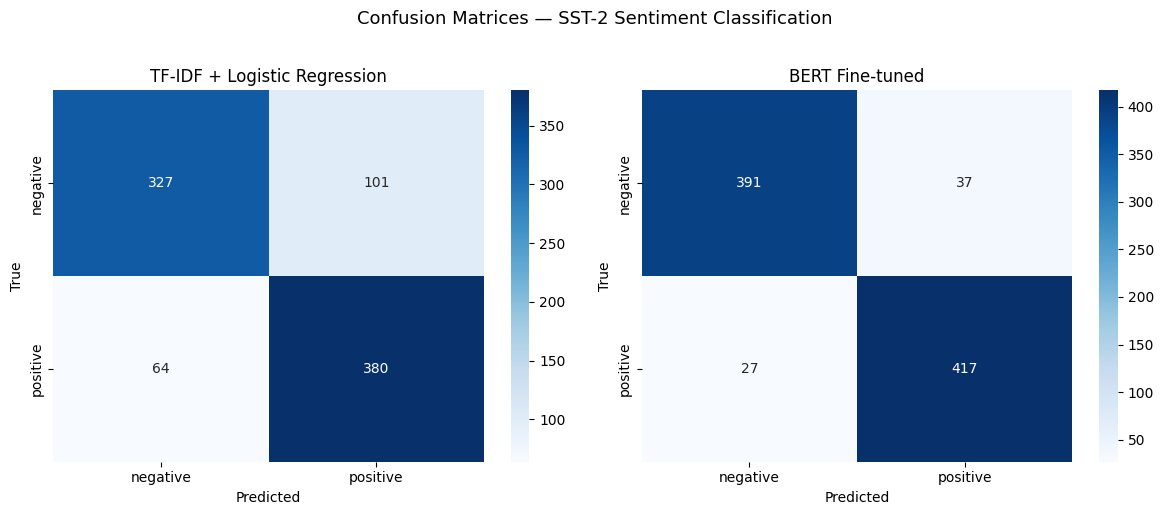

Saved outputs/confusion_matrix.png


In [ ]:
# --- Confusion matrix side by side: TF-IDF vs BERT ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(
    axes,
    [baseline_preds, bert_preds],
    ['TF-IDF + Logistic Regression', 'BERT Fine-tuned']
):
    cm = confusion_matrix(test_labels, preds)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=label_names, yticklabels=label_names, ax=ax
    )
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title)

plt.suptitle('Confusion Matrices — SST-2 Sentiment Classification', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved outputs/confusion_matrix.png')

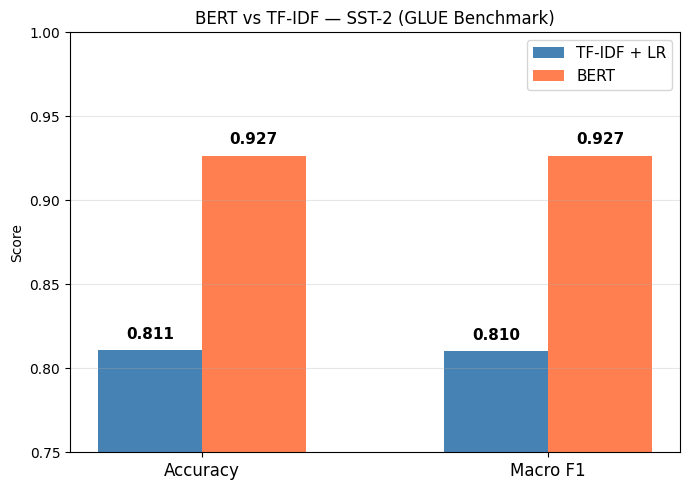

Saved outputs/model_comparison.png


In [ ]:
# --- Bar chart: Accuracy & F1 comparison ---
metrics   = ['Accuracy', 'Macro F1']
bl_vals   = [bl_acc,   bl_f1]
bert_vals = [bert_acc, bert_f1]

x = np.arange(len(metrics))
w = 0.3
fig, ax = plt.subplots(figsize=(7, 5))
bars1 = ax.bar(x - w/2, bl_vals,   w, label='TF-IDF + LR', color='steelblue')
bars2 = ax.bar(x + w/2, bert_vals, w, label='BERT',        color='coral')

for bar in bars1 + bars2:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f'{bar.get_height():.3f}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0.75, 1.0)
ax.set_ylabel('Score')
ax.set_title('BERT vs TF-IDF — SST-2 (GLUE Benchmark)')
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/model_comparison.png', dpi=150)
plt.show()
print('Saved outputs/model_comparison.png')

## 6. Final Summary

In [ ]:
print(f"{'Model':<25} {'Accuracy':>10} {'Macro F1':>10}")
print('-' * 47)
print(f"{'TF-IDF + LR':<25} {bl_acc:>10.4f} {bl_f1:>10.4f}")
print(f"{'BERT fine-tuned':<25} {bert_acc:>10.4f} {bert_f1:>10.4f}")
print(f"{'Delta (BERT - LR)':<25} {bert_acc-bl_acc:>+10.4f} {bert_f1-bl_f1:>+10.4f}")

results = {
    'dataset': 'SST-2 (GLUE Benchmark)',
    'model':   'bert-base-uncased',
    'baseline': {'accuracy': round(bl_acc, 4),  'macro_f1': round(bl_f1, 4)},
    'bert':     {'accuracy': round(bert_acc, 4), 'macro_f1': round(bert_f1, 4)},
    'delta':    {'accuracy': round(bert_acc-bl_acc, 4), 'macro_f1': round(bert_f1-bl_f1, 4)}
}
with open('outputs/results.json', 'w') as f:
    json.dump(results, f, indent=2)

print('\nSaved outputs/results.json')
print('\n--- CV Bullet Point ---')
print(f'Fine-tuned BERT on SST-2 (GLUE benchmark), achieving {bert_acc*100:.1f}% accuracy')
print(f'vs {bl_acc*100:.1f}% TF-IDF baseline (+{(bert_acc-bl_acc)*100:.1f}%), with full')
print('training pipeline: early stopping, cosine LR scheduling, F1/confusion matrix analysis.')

Model                       Accuracy   Macro F1
-----------------------------------------------
TF-IDF + LR                   0.8108     0.8101
BERT fine-tuned               0.9266     0.9265
Delta (BERT - LR)            +0.1158    +0.1165

Saved outputs/results.json

--- CV Bullet Point ---
Fine-tuned BERT on SST-2 (GLUE benchmark), achieving 92.7% accuracy
vs 81.1% TF-IDF baseline (+11.6%), with full
training pipeline: early stopping, cosine LR scheduling, F1/confusion matrix analysis.


In [ ]:
# Save model weights
trainer.save_model('outputs/bert_sst2_final')
tokenizer.save_pretrained('outputs/bert_sst2_final')
print('Model saved to outputs/bert_sst2_final/')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to outputs/bert_sst2_final/


In [ ]:
# Download everything
import shutil
shutil.make_archive('bert_sst2_results', 'zip', 'outputs')
from google.colab import files
files.download('bert_sst2_results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')